# Customer Churn Prediction

## Introduction

Customer churn is one of the most important challenges faced by banks and financial institutions.

When customers leave a bank and switch to another financial service provider, the organization may experience revenue loss, reduced customer loyalty, and increased costs associated with acquiring new customers.

Customer retention is generally more cost-effective than customer acquisition. Therefore, identifying customers who are likely to leave the bank is an important business objective.

With the help of data analysis and machine learning, it is possible to analyze customer information, identify patterns associated with customer behavior, and develop predictive models that estimate the likelihood of customer churn.

In this project, the Churn Modelling Dataset will be analyzed to understand customer characteristics, perform data cleaning, conduct exploratory data analysis (EDA), and develop classification models for predicting customer churn.

## Problem Statement

Customer churn is a major concern for banks and financial institutions because losing existing customers can negatively impact revenue, profitability, and long-term business growth.

Banks collect large amounts of customer information, including demographic details, account information, credit history, and banking activity. Analyzing this information can help identify customers who may be at risk of leaving the bank.

The objective of this project is to analyze customer data and identify the factors that influence customer churn.

Using historical customer records, machine learning models will be developed to predict whether a customer is likely to leave the bank.

The final model will be evaluated using classification performance metrics to measure its predictive capability and effectiveness.

## Project Objectives

The main objectives of this project are:

- Understand the structure and contents of the dataset
- Explore customer demographic and banking information
- Identify and handle missing values
- Perform data cleaning and preparation
- Encode categorical variables
- Conduct exploratory data analysis (EDA)
- Visualize important features affecting customer churn
- Build a machine learning classification model
- Evaluate model performance using classification metrics
- Analyze feature importance
- Generate meaningful insights from the analysis

## Dataset Information

This project uses the **Churn Modelling Dataset** obtained from Kaggle.

**Dataset Source:**  
https://www.kaggle.com/datasets/shrutimechlearn/churn-modelling

The dataset contains customer demographic information, banking details, account activity, and churn status records.

The primary objective of this dataset is to analyze customer behavior and identify factors that influence customer churn.

Each record represents an individual bank customer and contains information such as credit score, geography, gender, age, account balance, tenure, number of products, and estimated salary.

The target variable in this dataset is **Exited**, which indicates whether a customer left the bank or remained with the bank.

### Target Variable

| Value | Meaning |
|---------|---------|
| 0 | Customer Stayed |
| 1 | Customer Churned |

### Dataset Summary

| Attribute | Description |
|------------|------------|
| Dataset Name | Churn Modelling Dataset |
| Source | Kaggle |
| File Used | Churn_Modelling.csv |
| Problem Type | Binary Classification |
| Target Variable | Exited |
| Domain | Banking and Finance |

## Dataset Understanding and Description

Understanding the dataset is an important first step before data cleaning, analysis, and model development.

This project uses the Churn Modelling Dataset, which contains customer demographic information, financial details, and account-related attributes.

The objective is to predict whether a customer is likely to leave the bank based on customer characteristics and banking behavior.

### Dataset Features

| Feature | Description |
|----------|-------------|
| RowNumber | Record index number |
| CustomerId | Unique customer identifier |
| Surname | Customer surname |
| CreditScore | Customer credit score |
| Geography | Customer country/location |
| Gender | Customer gender |
| Age | Customer age |
| Tenure | Number of years with the bank |
| Balance | Account balance |
| NumOfProducts | Number of bank products used |
| HasCrCard | Credit card ownership status |
| IsActiveMember | Active membership status |
| EstimatedSalary | Estimated annual salary |
| Exited | Target variable indicating customer churn |

## Import Required Libraries

Before starting the analysis and machine learning process, the required Python libraries are imported.

These libraries provide functionalities for data loading, preprocessing, visualization, model development, feature importance analysis, and performance evaluation.

Pandas and NumPy are used for data manipulation and numerical operations.

Matplotlib and Seaborn are used for data visualization and exploratory data analysis.

Scikit-learn libraries are used for dataset splitting, machine learning model training, feature importance analysis, and model performance evaluation.

In [51]:
# Data Manipulation

import pandas as pd
import numpy as np

# Data Visualization

import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Model Evaluation

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

## Load Dataset

The Churn Modelling Dataset is loaded into a Pandas DataFrame for analysis.

A DataFrame is a tabular data structure consisting of rows and columns, similar to an Excel spreadsheet. It allows efficient data exploration, manipulation, and analysis.

A copy of the original dataset is also created to preserve the raw data while performing cleaning and preprocessing operations.

In [2]:
# Load dataset into a Pandas DataFrame

df = pd.read_csv("../datasets/Churn_Modelling.csv")

# Create a copy of the original dataset

# df_clean = df.copy()

## Dataset Preview

After loading the dataset, the first five records are displayed to verify that the dataset has been loaded successfully and to gain an initial understanding of its structure.

In [3]:
# Display first five records

df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
# Display the first five records of the dataset

df_clean.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## Data Cleaning and Preparation

Data cleaning is an important step in the machine learning workflow.

The objective of this phase is to identify missing values, verify dataset quality, and prepare the data for analysis and model development.

### Dataset Shape

Understanding the size of the dataset is an important step before performing data cleaning and analysis.

The shape of the dataset provides information about the total number of records and features available for customer churn prediction. This helps estimate the overall dataset size and understand the amount of information available for model development.

In [5]:
# Display the number of rows and columns in the dataset

print("Number of Rows and Columns:", df.shape)

Number of Rows and Columns: (10000, 14)


#### Observation

The dataset contains 10,000 rows and 14 columns.

Each row represents an individual bank customer, while each column represents a specific customer attribute such as demographic information, financial details, account activity, or churn status.

The dataset provides sufficient information for exploratory data analysis and machine learning model development.

With 10,000 customer records available, the dataset is suitable for building and evaluating customer churn prediction models.

### Dataset Information

Dataset information provides a detailed overview of the structure of the dataset.

This analysis helps identify data types, non-null values, and potential missing data issues that may require preprocessing before model training.

In [6]:
# Display information about the dataset

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.1 MB


#### Observation

The dataset contains 10,000 customer records and 14 features.

All features contain 10,000 non-null values, indicating that the dataset does not contain any missing values.

The dataset consists of both numerical and categorical variables.

Categorical features include Surname, Geography, and Gender, while the remaining features are numerical in nature.

The target variable, Exited, is represented as an integer variable and indicates whether a customer left the bank or remained with the bank.

The dataset occupies approximately 1.1 MB of memory and is suitable for exploratory data analysis and machine learning model development.

### Missing Values Analysis

Missing values are commonly found in real-world datasets and can affect the performance of machine learning models.

Before proceeding with analysis and model development, it is important to identify the amount of missing data present in each feature.

This analysis helps determine whether data cleaning and imputation techniques are required before model training.

In [7]:
# Display the number of missing values in each column

df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

#### Observation

The missing values analysis confirms that the dataset does not contain any missing values.

All 14 features contain complete information for all 10,000 customer records.

Since no missing values are present, no imputation or missing value handling techniques are required during the data cleaning process.

This indicates that the dataset is complete and ready for further preprocessing, exploratory data analysis, and machine learning model development.

### Duplicate Records Analysis

Duplicate records can affect dataset quality and lead to biased analytical results.

Therefore, the dataset is checked for duplicate entries to ensure that each record represents a unique customer before proceeding with further preprocessing and model development.

In [8]:
# Calculate the total number of duplicate records

print("Duplicate Records:",df.duplicated().sum())

Duplicate Records: 0


#### Observation

The duplicate records analysis confirms that no duplicate entries are present in the dataset.

Each record represents a unique bank customer, indicating that the dataset maintains good data quality and consistency.

Since no duplicate records were identified, no duplicate removal was required during the preprocessing stage.

### Encoding Categorical Variables

Machine learning algorithms require numerical input and cannot directly process categorical text values.

Therefore, categorical features must be converted into numerical representations before model training.

Before encoding, the unique values of each categorical feature are examined to understand the categories present in the dataset.

In [9]:
# Display unique values of categorical features

categorical_columns = [
    "Geography",
    "Gender"
]

for column in categorical_columns:
    print(f"{column}: {df[column].unique().tolist()}")

Geography: ['France', 'Spain', 'Germany']
Gender: ['Female', 'Male']


#### Observation

The categorical features contain a limited number of distinct categories, making them suitable for encoding.

The Gender feature contains two categories: Male and Female.

The Geography feature contains three categories: France, Spain, and Germany.

Since machine learning algorithms require numerical input, these categorical values will be converted into numerical representations during the encoding stage.

#### Encode Gender Feature

The Gender feature contains two categories and can be converted into numerical values using binary encoding.

Male customers will be represented as 1, while Female customers will be represented as 0.

This transformation allows the feature to be used by machine learning algorithms.

In [10]:
# Encode Gender feature

df_clean["Gender"] = df_clean["Gender"].map({
    "Male": 1,
    "Female": 0
})

#### Encode Geography Feature

The Geography feature contains multiple categories with no natural order or ranking.

Therefore, One-Hot Encoding is applied to create separate binary variables for each category and avoid introducing artificial relationships between locations.

The first category is dropped to prevent multicollinearity and reduce redundancy.

In [11]:
# Apply One-Hot Encoding to Geography

df_clean = pd.get_dummies(
    df_clean,
    columns=["Geography"],
    drop_first=True,
    dtype=int
)

#### Verify Encoded Values

After encoding, the dataset is reviewed to confirm that the categorical features have been successfully converted into numerical values.

This verification step ensures that the dataset is ready for machine learning algorithms.

In [12]:
# Display first ten records after encoding

df_clean.head(10)

,RowNumber,CustomerId,Surname,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain
0,1,15634602,Hargrave,619,0,42,2,0.00,1,1,1,101348.88,1,0,0
1,2,15647311,Hill,608,0,41,1,83807.86,1,0,1,112542.58,0,0,1
2,3,15619304,Onio,502,0,42,8,159660.80,3,1,0,113931.57,1,0,0
3,4,15701354,Boni,699,0,39,1,0.00,2,0,0,93826.63,0,0,0
4,5,15737888,Mitchell,850,0,43,2,125510.82,1,1,1,79084.10,0,0,1
5,6,15574012,Chu,645,1,44,8,113755.78,2,1,0,149756.71,1,0,1
6,7,15592531,Bartlett,822,1,50,7,0.00,2,1,1,10062.80,0,0,0
7,8,15656148,Obinna,376,0,29,4,115046.74,4,1,0,119346.88,1,1,0
8,9,15792365,He,501,1,44,4,142051.07,2,0,1,74940.50,0,0,0
9,10,15592389,H?,684,1,27,2,134603.88,1,1,1,71725.73,0,0,0


##### Observation

The categorical features were successfully converted into numerical representations.

The Gender feature was encoded using binary encoding, where Male is represented as 1 and Female is represented as 0.

The Geography feature was encoded using One-Hot Encoding. Since the first category was dropped to avoid multicollinearity, two new binary variables were created: Geography_Germany and Geography_Spain.

Customers belonging to France are represented when both Geography_Germany and Geography_Spain contain a value of 0.

The dataset is now suitable for machine learning algorithms that require numerical input features.

### Remove Unnecessary Features

Some features do not provide meaningful information for predicting customer churn.

RowNumber is simply a record index, CustomerId is a unique customer identifier, and Surname contains customer names.

These features do not contribute to customer churn prediction and may introduce unnecessary complexity into the model.

Therefore, they will be removed before further analysis and model development.

In [13]:
# Remove unnecessary features

df_clean = df_clean.drop(
    ["RowNumber", "CustomerId", "Surname"],
    axis=1
)

#### Verify Column Removal

The column names are displayed to confirm that the unnecessary features have been successfully removed from the dataset.

In [14]:
# Display column names after removing unnecessary features

df_clean.columns.tolist()

['CreditScore',
 'Gender',
 'Age',
 'Tenure',
 'Balance',
 'NumOfProducts',
 'HasCrCard',
 'IsActiveMember',
 'EstimatedSalary',
 'Exited',
 'Geography_Germany',
 'Geography_Spain']

##### Observation

The unnecessary features were successfully removed from the dataset.

The RowNumber feature was removed because it only represents the record index and does not contain predictive information.

The CustomerId feature was removed because it is a unique identifier and does not contribute to customer churn prediction.

The Surname feature was removed because customer names do not provide meaningful information for predicting churn behavior.

The remaining features consist of customer demographic information, financial attributes, banking activity indicators, and the target variable required for machine learning model development.

### Final Dataset Check

A final review of the dataset is performed after preprocessing to ensure that categorical variables have been encoded and unnecessary features have been removed.

This verification confirms that the dataset is ready for exploratory data analysis and machine learning model development.

In [15]:
# Display dataset information after preprocessing

df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CreditScore        10000 non-null  int64  
 1   Gender             10000 non-null  int64  
 2   Age                10000 non-null  int64  
 3   Tenure             10000 non-null  int64  
 4   Balance            10000 non-null  float64
 5   NumOfProducts      10000 non-null  int64  
 6   HasCrCard          10000 non-null  int64  
 7   IsActiveMember     10000 non-null  int64  
 8   EstimatedSalary    10000 non-null  float64
 9   Exited             10000 non-null  int64  
 10  Geography_Germany  10000 non-null  int64  
 11  Geography_Spain    10000 non-null  int64  
dtypes: float64(2), int64(10)
memory usage: 937.6 KB


#### Observation

The final dataset contains 10,000 customer records and 12 features after preprocessing.

All categorical variables have been successfully converted into numerical representations using binary encoding and One-Hot Encoding techniques.

The unnecessary features (RowNumber, CustomerId, and Surname) were removed because they do not contribute to customer churn prediction.

The dataset now consists entirely of numerical variables, including 10 integer features and 2 floating-point features.

With no missing values and all features in a machine-learning-friendly format, the dataset is fully prepared for exploratory data analysis and predictive modeling.

## Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is performed to understand the characteristics, patterns, and relationships within the dataset.

Through statistical summaries and visualizations, EDA helps identify important trends, distributions, and factors that may influence customer churn behavior.

The insights gained from this analysis can support feature understanding and improve machine learning model development.

### Descriptive Statistics

Descriptive statistics provide a summary of the numerical features in the dataset.

These statistics help understand the central tendency, variability, and overall distribution of the data by presenting measures such as count, mean, standard deviation, minimum value, maximum value, and quartiles.

This analysis provides an initial understanding of the dataset before performing detailed visualizations and feature-level exploration.

In [16]:
# Generate descriptive statistics for numerical features

df_clean.describe().T

,count,mean,std,min,25%,50%,75%,max
CreditScore,10000.0,650.528800,96.653299,350.00,584.00,652.000,718.0000,850.00
Gender,10000.0,0.545700,0.497932,0.00,0.00,1.000,1.0000,1.00
Age,10000.0,38.921800,10.487806,18.00,32.00,37.000,44.0000,92.00
Tenure,10000.0,5.012800,2.892174,0.00,3.00,5.000,7.0000,10.00
Balance,10000.0,76485.889288,62397.405202,0.00,0.00,97198.540,127644.2400,250898.09
NumOfProducts,10000.0,1.530200,0.581654,1.00,1.00,1.000,2.0000,4.00
HasCrCard,10000.0,0.705500,0.455840,0.00,0.00,1.000,1.0000,1.00
IsActiveMember,10000.0,0.515100,0.499797,0.00,0.00,1.000,1.0000,1.00
EstimatedSalary,10000.0,100090.239881,57510.492818,11.58,51002.11,100193.915,149388.2475,199992.48
Exited,10000.0,0.203700,0.402769,0.00,0.00,0.000,0.0000,1.00


#### Observation

The descriptive statistics provide an overview of the numerical features in the dataset.

The dataset contains 10,000 customer records, and all features have complete observations after preprocessing.

The average credit score is approximately 650, with values ranging from 350 to 850.

The average customer age is approximately 39 years, with ages ranging from 18 to 92 years.

Customers have an average tenure of approximately 5 years with the bank, while the number of products used by customers ranges from 1 to 4.

The average account balance is approximately 76,486, although some customers have a zero balance while the maximum balance exceeds 250,000.

The average estimated salary is approximately 100,090, with salaries ranging from 11.58 to nearly 200,000.

The target variable (Exited) has a mean value of 0.204, indicating that approximately 20% of customers in the dataset have churned, while the remaining customers stayed with the bank.

Overall, the descriptive statistics suggest substantial variation in customer demographics and financial characteristics, making the dataset suitable for customer churn analysis and predictive modeling.

### Customer Churn Distribution

The Exited feature is the target variable of the dataset.

Analyzing its distribution helps understand the proportion of customers who remained with the bank and those who left the bank.

Understanding the target variable distribution is important for evaluating class balance and model performance.

In [17]:
# Calculate customer churn distribution

df_clean["Exited"].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

#### Observation

The target variable distribution shows that 7,963 customers remained with the bank, while 2,037 customers left the bank.

This indicates that the dataset is imbalanced, with customer retention being significantly more common than customer churn.

Approximately 79.6% of customers remained with the bank, whereas 20.4% of customers exited.

Understanding this distribution is important because class imbalance can influence machine learning model performance and evaluation.

#### Customer Churn Distribution Visualization

A bar chart is used to visualize the distribution of customers who remained with the bank and those who exited.

This visualization provides a clear comparison between the two target classes and helps assess class balance within the dataset.

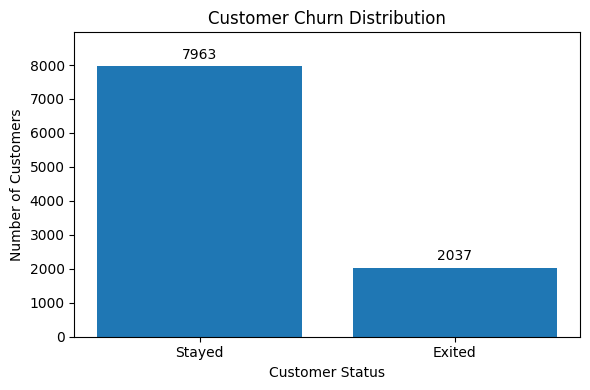

In [18]:
# Calculate churn distribution

churn_counts = df_clean["Exited"].value_counts()

# Create bar chart

plt.figure(figsize=(6,4))

bars = plt.bar(
    ["Stayed", "Exited"],
    [
        churn_counts[0],
        churn_counts[1]
    ]
)

# Add data labels

plt.bar_label(bars, padding=3)

# Add extra space at top

plt.ylim(0, max(churn_counts) + 1000)

plt.title("Customer Churn Distribution")
plt.xlabel("Customer Status")
plt.ylabel("Number of Customers")

# Save figure

plt.tight_layout()

plt.show()

##### Observation

The visualization shows that the majority of customers remained with the bank.

Out of 10,000 customers, 7,963 remained with the bank, while 2,037 customers exited.

Approximately 79.6% of customers stayed with the bank, whereas 20.4% of customers left the bank.

This indicates a noticeable class imbalance in the target variable, with customer retention being significantly more common than customer churn.

Although the dataset is imbalanced, both classes contain a sufficient number of observations for machine learning model training and evaluation.

Understanding this distribution is important because customer churn prediction models must correctly identify the smaller churned customer group despite the dominance of retained customers.

### Gender Distribution

Gender is an important demographic feature in the dataset.

Analyzing the gender distribution helps understand the representation of male and female customers and provides insight into the composition of the customer base.

In [19]:
# Calculate gender distribution

df_clean["Gender"].value_counts()

Gender
1    5457
0    4543
Name: count, dtype: int64

#### Observation

The gender distribution shows that 5,457 customers are male, while 4,543 customers are female.

Male customers account for approximately 54.6% of the dataset, whereas female customers represent approximately 45.4%.

The distribution is relatively balanced, with a slightly higher proportion of male customers.

This balanced representation ensures that both gender groups are adequately represented for customer churn analysis and machine learning model development.

#### Gender Distribution Visualization

A bar chart is used to visualize the distribution of male and female customers.

This visualization provides a clear comparison between the two gender categories and helps understand the composition of the customer base.

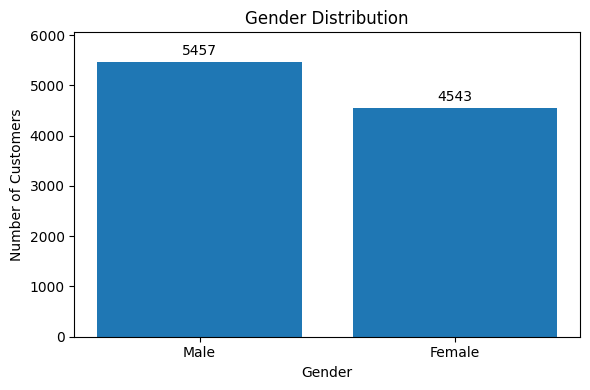

In [20]:
# Calculate gender distribution

gender_counts = df_clean["Gender"].value_counts()

# Create bar chart

plt.figure(figsize=(6,4))

bars = plt.bar(
    ["Male", "Female"],
    [
        gender_counts[1],
        gender_counts[0]
    ]
)

# Add data labels

plt.bar_label(bars, padding=3)

# Add extra space at top

plt.ylim(0, max(gender_counts) + 600)

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")

# Save figure

plt.tight_layout()

plt.show()

##### Observation

The visualization shows that male customers slightly outnumber female customers in the dataset.

Out of 10,000 customers, 5,457 are male and 4,543 are female.

Male customers account for approximately 54.6% of the customer base, while female customers represent approximately 45.4%.

The difference between the two groups is relatively small, indicating a fairly balanced gender distribution.

This balanced representation allows customer churn patterns to be analyzed across both gender groups without significant bias caused by unequal sample sizes.

### Customer Churn by Gender

Analyzing customer churn across gender categories helps determine whether gender has any relationship with customer retention behavior.

This analysis compares the number of customers who remained with the bank and those who exited within each gender group.

In [21]:
# Create churn by gender table

gender_churn = pd.crosstab(
    df_clean["Gender"],
    df_clean["Exited"]
)

gender_churn.index = [
    "Female(0)", 
    "Male(1)"
]

gender_churn.columns = [
    "Stayed(0)",
    "Exited(1)"
]

gender_churn

,Stayed(0),Exited(1)
Female(0),3404,1139
Male(1),4559,898


#### Observation

The churn analysis by gender shows that both male and female customers experienced customer churn.

Among female customers, 3,404 remained with the bank while 1,139 exited.

Among male customers, 4,559 remained with the bank while 898 exited.

Although male customers constitute a larger portion of the customer base, female customers have a higher number of churned customers relative to their population.

These results suggest that gender may have an influence on customer retention behavior and should be further explored through visualization and predictive modeling.

#### Customer Churn by Gender Visualization

A grouped bar chart is used to compare customer retention and churn across gender categories.

This visualization provides a side-by-side comparison of customers who remained with the bank and those who exited within each gender group.

The chart helps identify differences in churn behavior between male and female customers and provides a clearer understanding of the relationship between gender and customer churn.

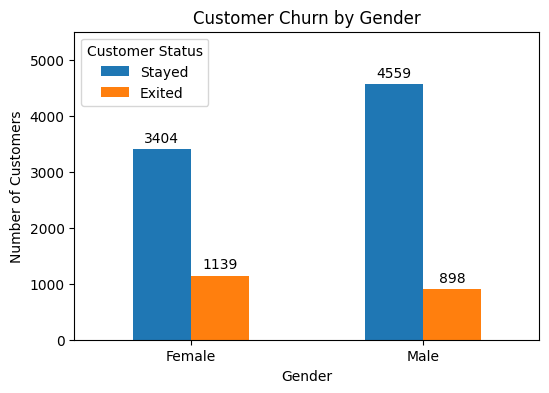

In [22]:
# Create bar chart

ax = gender_churn.plot(
    kind="bar",
    figsize=(6,4)
)

ax.set_xticklabels(
    ["Female", "Male"],
    rotation=0
)

# Add data labels

for container in ax.containers:
    ax.bar_label(
        container,
        padding=3
    )

plt.title("Customer Churn by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.legend(
    title="Customer Status",
    labels=["Stayed", "Exited"]
)

# Add extra space at top

plt.ylim(0, 5500)

plt.show()

##### Observation

The visualization compares customer retention and churn across gender categories.

Among female customers, 3,404 remained with the bank while 1,139 exited.

Among male customers, 4,559 remained with the bank while 898 exited.

The number of churned female customers is higher than the number of churned male customers, despite female customers representing a smaller portion of the customer base.

Similarly, male customers have a higher number of retained customers, which is consistent with their larger representation in the dataset.

These findings suggest that gender may have an influence on customer churn behavior and should be further investigated during predictive modeling and feature importance analysis.

### Geography Distribution

Geography is an important demographic feature that represents the country in which a customer resides.

Analyzing the geographical distribution helps understand the representation of customers across different countries and provides insight into the composition of the customer base.

In [23]:
# Calculate geography distribution

df["Geography"].value_counts()

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

#### Observation

The geography distribution shows that customers are distributed across three countries: France, Germany, and Spain.

France has the largest number of customers with 5,014 records, representing approximately 50.1% of the dataset.

Germany contains 2,509 customers, while Spain contains 2,477 customers.

The customer distribution indicates that approximately half of the customers are from France, whereas Germany and Spain contribute nearly equal proportions of the customer base.

This balanced representation across multiple countries provides an opportunity to analyze whether customer churn behavior differs by geographical location.

#### Geography Distribution Visualization

A bar chart is used to visualize the distribution of customers across different countries.

This visualization provides a clear comparison of customer representation in France, Germany, and Spain and helps understand the geographical composition of the customer base.

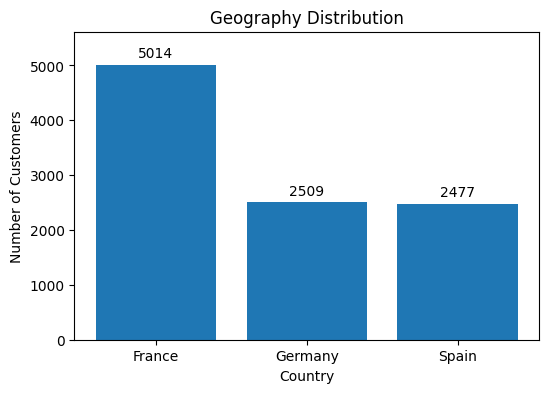

In [24]:
# Calculate geography distribution

geography_counts = df["Geography"].value_counts()

# Create bar chart

plt.figure(figsize=(6,4))

bars = plt.bar(
    geography_counts.index,
    geography_counts.values
)

# Add data labels

plt.bar_label(
    bars,
    padding=3
)

# Add extra space at top

plt.ylim(0, max(geography_counts) + 600)

plt.title("Geography Distribution")
plt.xlabel("Country")
plt.ylabel("Number of Customers")


plt.show()

##### Observation

The visualization shows the distribution of customers across France, Germany, and Spain.

France contains the largest customer base with 5,014 customers, accounting for approximately half of all customers in the dataset.

Germany and Spain have similar customer counts, with 2,509 and 2,477 customers respectively.

The difference between Germany and Spain is relatively small, indicating a balanced representation between these two countries.

The geographical distribution suggests that France is the dominant market in the dataset, while Germany and Spain contribute nearly equal proportions of customers.

These findings provide a foundation for further analysis to determine whether customer churn behavior varies across different countries.

### Customer Churn by Geography

Analyzing customer churn across geographical locations helps determine whether customers from certain countries are more likely to leave the bank.

This analysis compares customer retention and churn across France, Germany, and Spain to identify geographical differences in customer behavior.

In [25]:
# Calculate customer churn by geography

geography_churn = pd.crosstab(
    df["Geography"],
    df["Exited"]
)

geography_churn.columns = [
    "Stayed(0)",
    "Exited(1)"
]

geography_churn

,Stayed(0),Exited(1)
Geography,,
France,4204,810
Germany,1695,814
Spain,2064,413


#### Observation

The churn analysis by geography reveals noticeable differences in customer retention and churn across countries.

France has the largest customer base, with 4,204 customers remaining and 810 customers exiting.

Germany has 1,695 retained customers and 814 churned customers. Despite having fewer total customers than France, Germany has nearly the same number of churned customers.

Spain has 2,064 retained customers and 413 churned customers, representing the lowest number of churned customers among the three countries.

The results suggest that customer churn is considerably higher in Germany compared to France and Spain.

These findings indicate that geographical location may play an important role in customer churn behavior and could be a significant predictor in the machine learning model.

#### Customer Churn by Geography Visualization

A grouped bar chart is used to compare customer retention and churn across different countries.

This visualization provides a side-by-side comparison of customers who remained with the bank and those who exited in France, Germany, and Spain.

The chart helps identify geographical differences in customer churn behavior and highlights countries with higher customer attrition.

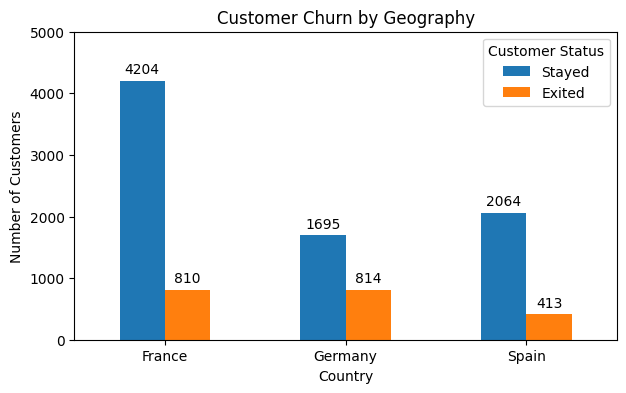

In [26]:
# Create bar chart

ax = geography_churn.plot(
    kind="bar",
    figsize=(7,4)
)

ax.set_xticklabels(
    ["France", "Germany", "Spain"],
    rotation=0
)

# Add data labels

for container in ax.containers:
    ax.bar_label(
        container,
        padding=3
    )

plt.title("Customer Churn by Geography")
plt.xlabel("Country")
plt.ylabel("Number of Customers")

plt.legend(
    title="Customer Status",
    labels=["Stayed", "Exited"]
)

# Add extra space at top

plt.ylim(0, 5000)

plt.show()

##### Observation

The visualization compares customer retention and churn across France, Germany, and Spain.

France has the largest number of customers, with 4,204 customers remaining and 810 customers exiting.

Germany has 1,695 retained customers and 814 churned customers. Despite having significantly fewer customers than France, Germany has a nearly identical number of churned customers.

Spain shows the lowest level of customer churn, with 2,064 retained customers and 413 churned customers.

The results indicate that customer churn is substantially higher in Germany relative to its customer base compared to France and Spain.

These findings suggest that geography may be an important factor influencing customer churn behavior and could play a significant role in predictive modeling.

### Age Distribution

Age is an important customer characteristic that may influence banking behavior and customer retention.

Analyzing the age distribution helps understand the age composition of customers and identify the most common age groups within the dataset.

This analysis may also provide insights into whether certain age groups are more likely to leave the bank.

In [27]:
# Generate descriptive statistics for age

df_clean["Age"].describe()

count    10000.000000
mean        38.921800
std         10.487806
min         18.000000
25%         32.000000
50%         37.000000
75%         44.000000
max         92.000000
Name: Age, dtype: float64

#### Observation

The age statistics provide an overview of the customer age distribution within the dataset.

The average customer age is approximately 38.9 years, while the median age is 37 years.

Customer ages range from 18 to 92 years, indicating that the dataset includes both young and senior customers.

The middle 50% of customers are between 32 and 44 years old, as indicated by the first quartile (32 years) and third quartile (44 years).

The relatively small difference between the mean age (38.9 years) and median age (37 years) suggests that the age distribution is fairly balanced, although the presence of older customers may contribute to a slight right skew.

These statistics indicate that the dataset primarily consists of middle-aged customers, with a broad range of ages represented across the customer base.

#### Age Distribution Visualization

A histogram is used to visualize the distribution of customer ages.

This visualization helps identify the most common age groups, the overall shape of the age distribution, and the presence of any unusual patterns or extreme age values.

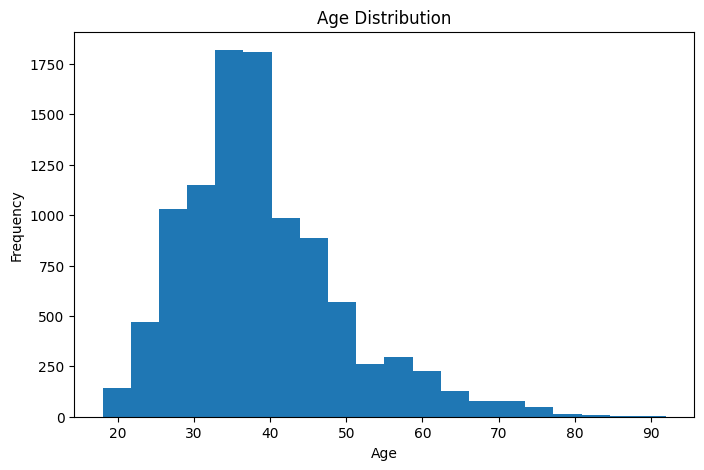

In [28]:
# Create histogram for age distribution

plt.figure(figsize=(8,5))

plt.hist(
    df_clean["Age"],
    bins=20
)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

##### Observation

The histogram shows that the majority of customers are between 30 and 45 years of age.

The highest concentration of customers falls within the age range of approximately 30 to 40 years, indicating that middle-aged customers form the largest segment of the customer base.

The distribution is positively skewed, with the frequency of customers gradually decreasing as age increases.

A smaller number of customers are observed in the higher age groups, particularly above 60 years of age.

The presence of customers up to 92 years old creates a long right tail in the distribution, suggesting that older customers are less common in the dataset.

Overall, the customer base is dominated by middle-aged individuals, while younger and older age groups are comparatively less represented.

#### Age Box Plot

A box plot is used to visualize the spread of customer ages and identify potential outliers.

This visualization provides a summary of the age distribution by displaying the median, interquartile range, and any extreme age values present in the dataset.

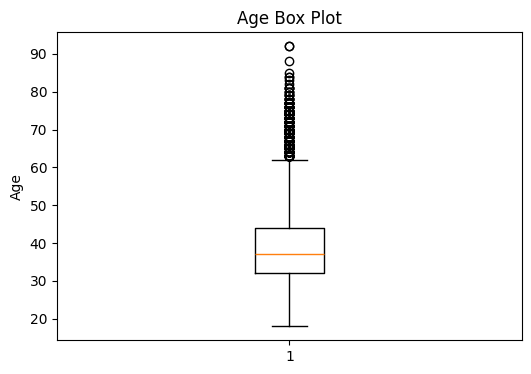

In [29]:
# Create box plot for age

plt.figure(figsize=(6,4))

plt.boxplot(
    df_clean["Age"]
)

plt.title("Age Box Plot")
plt.ylabel("Age")

plt.show()

##### Observation

The box plot provides a summary of the age distribution and highlights the presence of potential outliers.

The median customer age is approximately 37 years, which is consistent with the descriptive statistics.

The middle 50% of customers are concentrated between approximately 32 and 44 years of age, indicating that most customers belong to the middle-aged population.

Several outliers are visible above the upper whisker, primarily representing customers older than 60 years of age.

These observations suggest that while most customers fall within a relatively narrow age range, the dataset also contains a smaller group of significantly older customers.

Since these age values represent real customers rather than data entry errors, no outlier removal is required at this stage.

#### Outlier Analysis

The box plot identifies several age outliers, primarily among older customers.

These observations represent genuine customer records rather than data quality issues.

Therefore, no outlier removal is performed, and all records are retained to preserve the original characteristics of the dataset.

### Credit Score Distribution

Credit score is one of the most important financial indicators used to assess a customer's creditworthiness.

Analyzing the distribution of credit scores helps understand the overall credit profile of customers and identify the presence of low-risk and high-risk customer groups.

This analysis may provide insights into whether credit score influences customer churn behavior.

In [30]:
# Generate descriptive statistics for credit score

df_clean["CreditScore"].describe()

count    10000.000000
mean       650.528800
std         96.653299
min        350.000000
25%        584.000000
50%        652.000000
75%        718.000000
max        850.000000
Name: CreditScore, dtype: float64

#### Observation

The credit score statistics provide an overview of the customers' creditworthiness within the dataset.

The average credit score is approximately 650.5, while the median credit score is 652.

Credit scores range from 350 to 850, indicating substantial variation in customer credit profiles.

The middle 50% of customers have credit scores between 584 and 718, suggesting that most customers fall within the fair to good credit score range.

The mean and median values are very close, indicating that the credit score distribution is relatively symmetric and does not exhibit strong skewness.

Overall, the dataset contains customers with a wide range of credit scores, from high-risk individuals with low scores to highly creditworthy customers with excellent scores.

#### Credit Score Distribution Visualization

A histogram is used to visualize the distribution of customer credit scores.

This visualization helps identify the most common credit score ranges, the overall shape of the distribution, and the presence of any unusual patterns within the customer base.

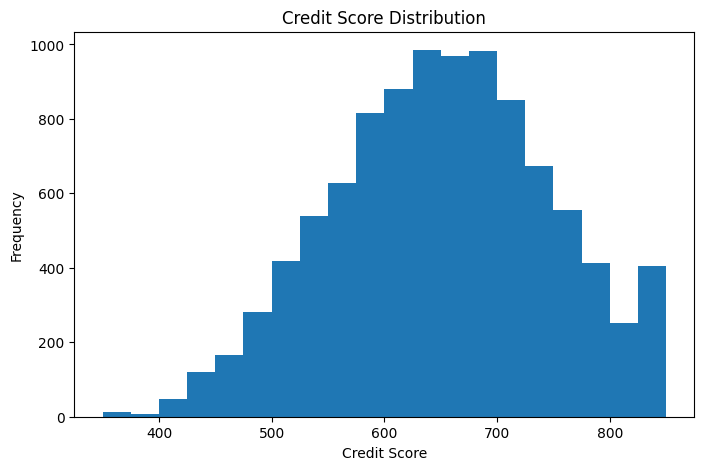

In [31]:
# Create histogram for credit score distribution

plt.figure(figsize=(8,5))

plt.hist(
    df_clean["CreditScore"],
    bins=20
)

plt.title("Credit Score Distribution")
plt.xlabel("Credit Score")
plt.ylabel("Frequency")

plt.show()

##### Observation

The histogram shows the distribution of customer credit scores across the dataset.

Most customers have credit scores between approximately 550 and 750, indicating that the majority of customers fall within the average to good credit score range.

The highest concentration of customers is observed around the 650 to 700 credit score range, which is consistent with the mean credit score of approximately 650.5 and the median credit score of 652.

The distribution appears relatively symmetric, with customer frequencies gradually decreasing toward both the lower and higher credit score ranges.

Only a small number of customers have extremely low credit scores below 450 or exceptionally high credit scores above 800.

Overall, the credit score distribution suggests that the dataset is dominated by customers with moderate to good credit profiles, while very low-risk and very high-risk customers are less common.

#### Credit Score Box Plot

A box plot is used to visualize the spread of customer credit scores and identify potential outliers.

This visualization provides a concise summary of the distribution by displaying the median, interquartile range, and any extreme credit score values present in the dataset.

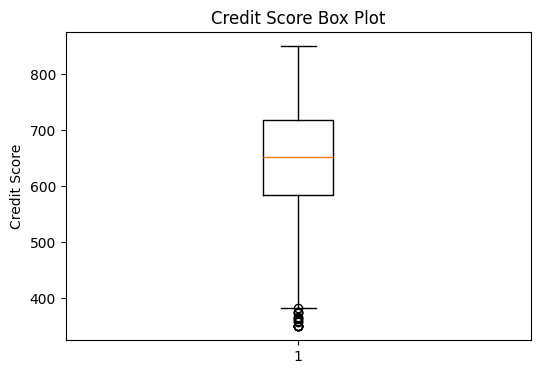

In [32]:
# Create box plot for credit score

plt.figure(figsize=(6,4))

plt.boxplot(
    df_clean["CreditScore"]
)

plt.title("Credit Score Box Plot")
plt.ylabel("Credit Score")

plt.show()

##### Observation

The box plot provides a summary of the credit score distribution and highlights the presence of potential outliers.

The median credit score is approximately 652, which is consistent with the descriptive statistics.

The middle 50% of customers have credit scores between approximately 584 and 718, indicating that most customers fall within the average to good credit score range.

A small number of outliers are visible below the lower whisker, representing customers with exceptionally low credit scores.

No significant outliers are observed on the higher end of the distribution, suggesting that extremely high credit scores are less unusual within the dataset.

Overall, the credit score distribution appears relatively balanced, with only a few low-score outliers present in the customer base.

#### Outlier Analysis

The box plot identifies a small number of low credit score outliers.

These observations represent genuine customer credit profiles rather than data quality issues or data entry errors.

Since low credit scores are expected in real-world banking data and may carry important predictive information, no outlier removal is performed.

All records are retained to preserve the original characteristics of the dataset.

### Balance Distribution

Balance represents the amount of money held by a customer in their bank account.

Analyzing the balance distribution helps understand customer financial behavior, identify common balance ranges, and detect the presence of unusual account balances.

This analysis may provide insights into whether account balance influences customer churn behavior.

In [33]:
# Generate descriptive statistics for balance

df_clean["Balance"].describe()

count     10000.000000
mean      76485.889288
std       62397.405202
min           0.000000
25%           0.000000
50%       97198.540000
75%      127644.240000
max      250898.090000
Name: Balance, dtype: float64

#### Observation

The balance statistics reveal substantial variation in customer account balances.

The average account balance is approximately 76,486, while the median balance is approximately 97,199.

The minimum balance is 0, indicating that some customers do not maintain funds in their accounts, while the maximum balance exceeds 250,898.

The first quartile (25%) is equal to 0, which means that at least 25% of customers have a zero account balance.

The large difference between the minimum and maximum values, combined with a high standard deviation of approximately 62,397, suggests considerable variability in customer balances.

Additionally, the median balance is noticeably higher than the mean balance, indicating that a large number of customers have either zero balances or relatively low balances, which lowers the overall average.

These findings suggest that customer balances are not evenly distributed and that account balance may be an important factor influencing customer behavior and churn.

#### Balance Distribution Visualization

A histogram is used to visualize the distribution of customer account balances.

This visualization helps identify common balance ranges, understand the overall shape of the distribution, and detect unusual patterns within customer account balances.

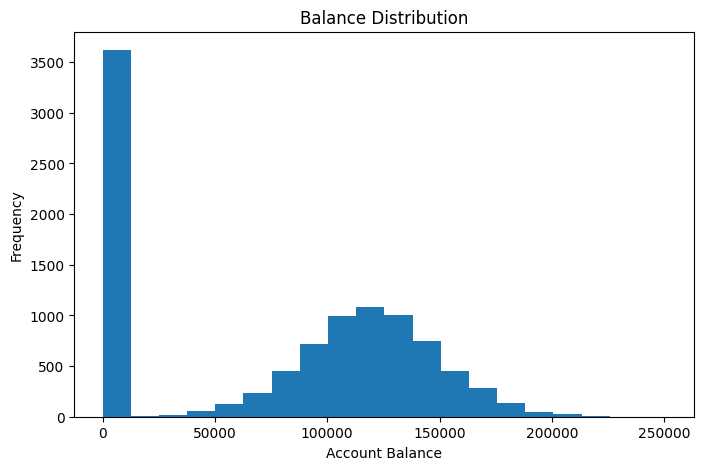

In [34]:
# Create histogram for balance distribution

plt.figure(figsize=(8,5))

plt.hist(
    df_clean["Balance"],
    bins=20
)

plt.title("Balance Distribution")
plt.xlabel("Account Balance")
plt.ylabel("Frequency")

plt.show()

##### Observation

The histogram reveals a unique distribution pattern in customer account balances.

A large concentration of customers has an account balance of zero, which is reflected by the prominent spike at the beginning of the distribution.

Apart from the zero-balance customers, most account balances are concentrated between approximately 80,000 and 150,000.

The distribution of non-zero balances appears relatively bell-shaped, with the highest frequency occurring around 120,000.

Customer balances gradually decrease in frequency as the balance amount moves away from this central range.

A small number of customers maintain very high account balances exceeding 200,000, indicating the presence of high-value account holders.

Overall, the histogram suggests that the dataset contains two distinct groups of customers: those with zero balances and those maintaining moderate to high account balances. This pattern may be important for understanding customer behavior and predicting customer churn.

#### Balance Box Plot

A box plot is used to visualize the spread of customer account balances and identify potential outliers.

This visualization provides a concise summary of the balance distribution by displaying the median, interquartile range, and any extreme balance values present in the dataset.

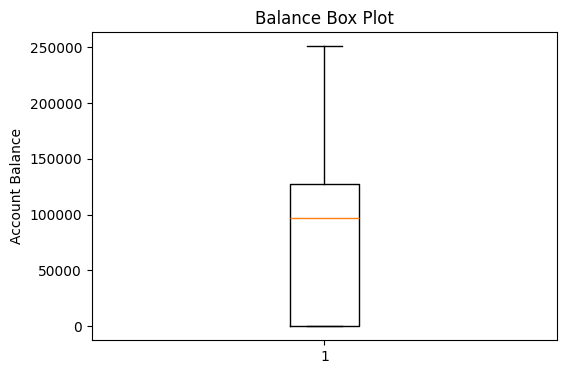

In [35]:
# Create box plot for balance

plt.figure(figsize=(6,4))

plt.boxplot(
    df_clean["Balance"]
)

plt.title("Balance Box Plot")
plt.ylabel("Account Balance")

plt.show()

##### Observation

The box plot provides a summary of the customer account balance distribution.

The median account balance is approximately 97,199, which is consistent with the descriptive statistics.

The lower quartile (25%) is equal to 0, indicating that at least one-quarter of customers have no balance in their accounts.

The middle 50% of customers have balances between approximately 0 and 127,644, reflecting substantial variation in customer account balances.

The balance values extend from 0 to approximately 250,898, demonstrating a wide range of account balances across customers.

Unlike the Age and Credit Score features, the box plot does not reveal any significant outliers beyond the whiskers.

Overall, the balance distribution shows considerable variability and highlights the presence of a large group of customers with zero account balances.

#### Outlier Analysis

The box plot does not indicate the presence of significant balance outliers beyond the whiskers.

The wide range of balance values appears to be a natural characteristic of the customer population rather than the result of data quality issues.

Therefore, no outlier removal is required, and all customer records are retained for further analysis and model development.

### Estimated Salary Distribution

Estimated salary represents the annual income estimated for each customer.

Analyzing the salary distribution helps understand the income characteristics of customers and identify whether salary levels vary substantially across the customer base.

This analysis may provide insights into whether customer income influences churn behavior.

In [36]:
# Generate descriptive statistics for estimated salary

df_clean["EstimatedSalary"].describe()

count     10000.000000
mean     100090.239881
std       57510.492818
min          11.580000
25%       51002.110000
50%      100193.915000
75%      149388.247500
max      199992.480000
Name: EstimatedSalary, dtype: float64

#### Observation

The estimated salary statistics provide an| overview of customer income levels within the dataset.

The average estimated salary is approximately 100,090, while the median estimated salary is approximately 100,194.

Estimated salaries range from approximately 11.58 to 199,992.48, indicating a wide variation in customer income levels.

The middle 50% of customers have estimated salaries between approximately 51,002 and 149,388.

The mean and median values are nearly identical, suggesting that the salary distribution is highly balanced and does not exhibit significant skewness.

The large standard deviation of approximately 57,510 reflects substantial variability in customer salaries across the dataset.

Overall, the dataset contains customers with diverse income levels, ranging from very low estimated salaries to high-income individuals.

#### Estimated Salary Distribution Visualization

A histogram is used to visualize the distribution of customer estimated salaries.

This visualization helps identify common salary ranges, understand the overall shape of the distribution, and detect any unusual patterns within customer income levels.

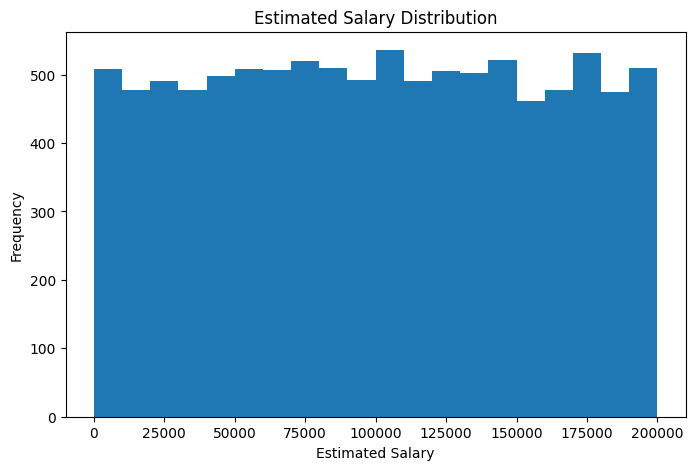

In [37]:
# Create histogram for estimated salary distribution

plt.figure(figsize=(8,5))

plt.hist(
    df_clean["EstimatedSalary"],
    bins=20
)

plt.title("Estimated Salary Distribution")
plt.xlabel("Estimated Salary")
plt.ylabel("Frequency")

plt.show()

##### Observation

The histogram shows the distribution of estimated salaries across the customer base.

Unlike the Age, Credit Score, and Balance distributions, the estimated salary distribution appears relatively uniform across the entire salary range.

Customers are distributed fairly evenly between approximately 0 and 200,000, with no single salary range dominating the dataset.

The frequencies across the histogram bins remain relatively consistent, indicating that customers with low, medium, and high estimated salaries are represented in similar proportions.

The absence of strong peaks or clusters suggests that estimated salary is evenly distributed throughout the customer population.

Overall, the distribution indicates that the dataset contains customers from a wide range of income levels, providing a balanced representation of estimated salaries.

#### Estimated Salary Box Plot

A box plot is used to visualize the spread of estimated salaries and identify potential outliers.

This visualization provides a concise summary of the salary distribution by displaying the median, interquartile range, and any extreme salary values present in the dataset.

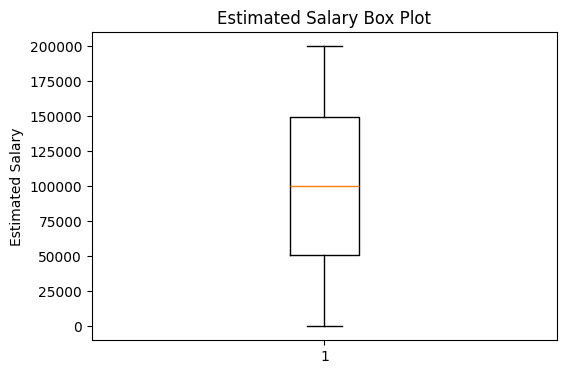

In [38]:
# Create box plot for estimated salary

plt.figure(figsize=(6,4))

plt.boxplot(
    df_clean["EstimatedSalary"]
)

plt.title("Estimated Salary Box Plot")
plt.ylabel("Estimated Salary")

plt.show()

##### Observation

The box plot provides a summary of the estimated salary distribution across customers.

The median estimated salary is approximately 100,194, which is consistent with the descriptive statistics.

The middle 50% of customers have estimated salaries between approximately 51,002 and 149,388, indicating a broad spread of income levels within the customer base.

The salary values extend from approximately 11.58 to 199,992.48, demonstrating a wide range of estimated salaries.

Unlike the Age and Credit Score features, no significant outliers are visible beyond the whiskers, indicating that the salary distribution is well balanced.

The relatively symmetric box and whiskers further support the observation that estimated salaries are evenly distributed across the dataset.

Overall, the estimated salary feature exhibits a stable distribution with substantial variability but without extreme outlier values.

#### Outlier Analysis

The box plot does not reveal any significant outliers in the estimated salary feature.

The observed salary range appears to be a natural characteristic of the customer population rather than the result of data quality issues.

Therefore, no outlier removal is required, and all customer records are retained for further analysis and predictive modeling.

### Customer Churn by Active Membership

Customer activity status indicates whether a customer actively uses banking services.

Analyzing churn across active and inactive customers helps determine whether customer engagement influences churn behavior.

This analysis compares customer retention and churn between active and inactive customers to identify potential behavioral patterns.

In [39]:
# Calculate customer churn by active membership

active_churn = pd.crosstab(
    df_clean["IsActiveMember"],
    df_clean["Exited"]
)

active_churn.index = [
    "Inactive(0)",
    "Active(1)"
]

active_churn.columns = [
    "Stayed(0)",
    "Exited(1)"
]

active_churn

,Stayed(0),Exited(1)
Inactive(0),3547,1302
Active(1),4416,735


#### Observation

The churn analysis highlights a noticeable difference between active and inactive customers.

Among inactive customers, 3,547 remained with the bank while 1,302 exited.

In contrast, active customers show stronger retention, with 4,416 customers remaining and only 735 customers exiting.

Although both groups contain a large number of retained customers, the number of churned customers is considerably higher among inactive customers.

The results suggest that customers who actively use banking services are less likely to leave the bank compared to inactive customers.

These findings indicate that customer activity status may be an important factor influencing customer churn and could serve as a valuable predictor in the machine learning model.

### Customer Churn by Number of Products

The number of products represents how many banking products a customer uses.

Analyzing churn across different product counts helps determine whether product usage influences customer retention and churn behavior.

This analysis compares customer retention and churn across customers with different numbers of products.

In [40]:
# Calculate customer churn by number of products

products_churn = pd.crosstab(
    df_clean["NumOfProducts"],
    df_clean["Exited"]
)

products_churn.columns = [
    "Stayed(0)",
    "Exited(1)"
]

products_churn

,Stayed(0),Exited(1)
NumOfProducts,,
1,3675,1409
2,4242,348
3,46,220
4,0,60


#### Observation

The churn analysis based on the number of products reveals significant differences in customer retention and churn behavior.

Customers with 1 product represent the largest group, with 3,675 customers remaining and 1,409 customers exiting.

Customers with 2 products show the strongest retention, with 4,242 customers remaining and only 348 customers exiting.

For customers with 3 products, the number of churned customers (220) is substantially higher than the number of retained customers (46).

Customers with 4 products exhibit the highest churn behavior, as all 60 customers in this category exited the bank and none remained.

These findings suggest that customers using 2 products are the most loyal group, while customers with 3 or 4 products are significantly more likely to leave the bank.

The number of products appears to be a highly influential feature and may play an important role in predicting customer churn.

#### Customer Churn by Number of Products Visualization

A grouped bar chart is used to compare customer retention and churn across different product categories.

This visualization provides a side-by-side comparison of customers who remained with the bank and those who exited for each product count.

The chart helps identify how product usage is associated with customer churn behavior.

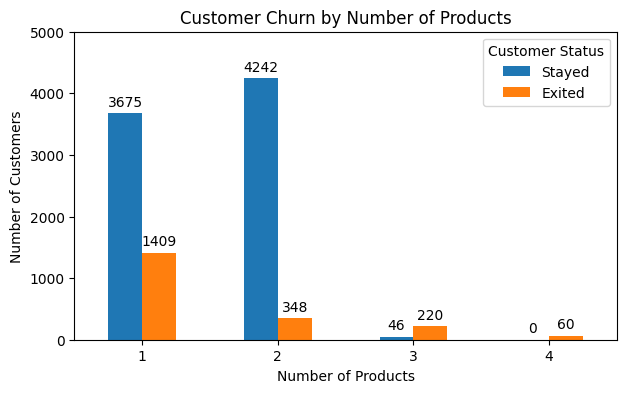

In [41]:
# Create bar chart

ax = products_churn.plot(
    kind="bar",
    figsize=(7,4)
)

ax.tick_params(axis="x", rotation=0)

# Add data labels

for container in ax.containers:
    ax.bar_label(
        container,
        padding=3
    )

plt.title("Customer Churn by Number of Products")
plt.xlabel("Number of Products")
plt.ylabel("Number of Customers")

plt.legend(
    title="Customer Status",
    labels=["Stayed", "Exited"]
)

# Add extra space at top

plt.ylim(0, 5000)

plt.show()

##### Observation

The visualization compares customer retention and churn across different product categories.

Customers with 1 product show a relatively high level of churn, with 1,409 customers exiting compared to 3,675 customers remaining.

Customers with 2 products exhibit the strongest retention behavior, with 4,242 customers remaining and only 348 customers exiting.

A significant shift is observed among customers with 3 products, where the number of churned customers (220) exceeds the number of retained customers (46).

The most extreme pattern is observed among customers with 4 products, where all 60 customers exited the bank and none remained.

These findings suggest that customers holding 2 products are the most loyal segment, while customers with 3 or 4 products are substantially more likely to leave the bank.

Overall, the number of products appears to be one of the strongest factors associated with customer churn and may play an important role in predictive modeling.

### Customer Churn by Credit Card Status

Credit card ownership indicates whether a customer possesses a bank-issued credit card.

Analyzing churn across customers with and without credit cards helps determine whether credit card ownership influences customer retention and churn behavior.

This analysis compares customer retention and churn between customers who have a credit card and those who do not.

In [42]:
# Calculate customer churn by credit card status

card_churn = pd.crosstab(
    df_clean["HasCrCard"],
    df_clean["Exited"]
)

card_churn.index = [
    "No Credit Card(0)",
    "Credit Card(1)"
]

card_churn.columns = [
    "Stayed(0)",
    "Exited(1)"
]

card_churn

,Stayed(0),Exited(1)
No Credit Card(0),2332,613
Credit Card(1),5631,1424


#### Observation

The churn analysis based on credit card ownership shows that customers with and without credit cards exhibit similar retention patterns.

Among customers without a credit card, 2,332 remained with the bank while 613 exited.

Among customers with a credit card, 5,631 remained with the bank while 1,424 exited.

Although customers with credit cards account for a larger share of both retained and churned customers, this is largely due to their greater representation in the dataset.

The difference in churn behavior between the two groups does not appear to be as pronounced as the differences observed for active membership status or number of products.

These findings suggest that credit card ownership may have a relatively limited influence on customer churn compared to other customer characteristics.

#### Customer Churn by Credit Card Status Visualization

A grouped bar chart is used to compare customer retention and churn between customers with and without a credit card.

This visualization provides a side-by-side comparison of retained and churned customers and helps assess whether credit card ownership is associated with customer churn behavior.

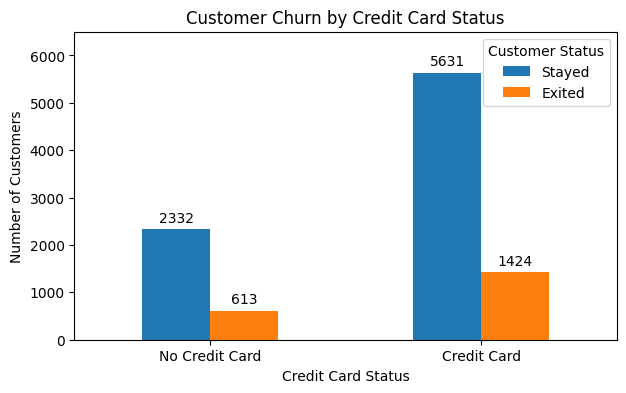

In [43]:
# Create bar chart

ax = card_churn.plot(
    kind="bar",
    figsize=(7,4)
)

ax.set_xticklabels(
    ["No Credit Card", "Credit Card"],
    rotation=0
)

# Add data labels

for container in ax.containers:
    ax.bar_label(
        container,
        padding=3
    )

plt.title("Customer Churn by Credit Card Status")
plt.xlabel("Credit Card Status")
plt.ylabel("Number of Customers")

plt.legend(
    title="Customer Status",
    labels=["Stayed", "Exited"]
)

# Add extra space at top

plt.ylim(0, 6500)


plt.show()

#### Observation

The visualization compares customer retention and churn between customers with and without a credit card.

Customers with a credit card represent the larger group in the dataset, with 5,631 customers remaining and 1,424 customers exiting.

Customers without a credit card show 2,332 retained customers and 613 churned customers.

Both groups display a similar pattern, where the number of retained customers is substantially higher than the number of churned customers.

Unlike the patterns observed for active membership status and number of products, credit card ownership does not appear to create a strong separation between retained and churned customers.

These findings suggest that credit card ownership has a relatively weak relationship with customer churn and may contribute less predictive value than other customer characteristics.

### Correlation Analysis

Correlation analysis is performed to examine the relationships between numerical features in the dataset.

Understanding these relationships helps identify variables that may influence customer churn and provides insights into potential patterns within the data.

The analysis also supports feature selection and interpretation during machine learning model development.

In [44]:
# Calculate correlation matrix

df_clean.corr()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain
CreditScore,1.000000,-0.002857,-0.003965,0.000842,0.006268,0.012238,-0.005458,0.025651,-0.001384,-0.027094,0.005538,0.004780
Gender,-0.002857,1.000000,-0.027544,0.014733,0.012087,-0.021859,0.005766,0.022544,-0.008112,-0.106512,-0.024628,0.016889
Age,-0.003965,-0.027544,1.000000,-0.009997,0.028308,-0.030680,-0.011721,0.085472,-0.007201,0.285323,0.046897,-0.001685
Tenure,0.000842,0.014733,-0.009997,1.000000,-0.012254,0.013444,0.022583,-0.028362,0.007784,-0.014001,-0.000567,0.003868
Balance,0.006268,0.012087,0.028308,-0.012254,1.000000,-0.304180,-0.014858,-0.010084,0.012797,0.118533,0.401110,-0.134892
NumOfProducts,0.012238,-0.021859,-0.030680,0.013444,-0.304180,1.000000,0.003183,0.009612,0.014204,-0.047820,-0.010419,0.009039
HasCrCard,-0.005458,0.005766,-0.011721,0.022583,-0.014858,0.003183,1.000000,-0.011866,-0.009933,-0.007138,0.010577,-0.013480
IsActiveMember,0.025651,0.022544,0.085472,-0.028362,-0.010084,0.009612,-0.011866,1.000000,-0.011421,-0.156128,-0.020486,0.016732
EstimatedSalary,-0.001384,-0.008112,-0.007201,0.007784,0.012797,0.014204,-0.009933,-0.011421,1.000000,0.012097,0.010297,-0.006482
Exited,-0.027094,-0.106512,0.285323,-0.014001,0.118533,-0.047820,-0.007138,-0.156128,0.012097,1.000000,0.173488,-0.052667


#### Observation

The correlation matrix shows the relationships between numerical features in the dataset.

Most features exhibit weak to moderate correlations with customer churn, indicating that customer churn is influenced by multiple factors rather than a single variable.

Among all features, Age shows the strongest positive correlation with churn (0.285), suggesting that older customers are more likely to leave the bank.

Geography_Germany has a positive correlation with churn (0.173), indicating that customers from Germany tend to have higher churn rates compared to customers from other countries.

Balance also exhibits a positive correlation with churn (0.119), suggesting that customers with higher account balances are slightly more likely to exit.

IsActiveMember has a negative correlation with churn (-0.156), indicating that active customers are less likely to leave the bank.

Gender shows a weak negative correlation with churn (-0.107), while Credit Score, Tenure, HasCrCard, and Estimated Salary exhibit very weak relationships with customer churn.

Overall, Age, Geography, Balance, Active Membership, and Number of Products appear to be the most influential features for predicting customer churn.

#### Correlation Heatmap

A correlation heatmap is used to visualize the strength and direction of relationships between features in the dataset.

The heatmap provides a color-coded representation of correlation coefficients, making it easier to identify features that are positively or negatively associated with customer churn.

This analysis helps highlight important predictors and supports feature selection for machine learning model development.

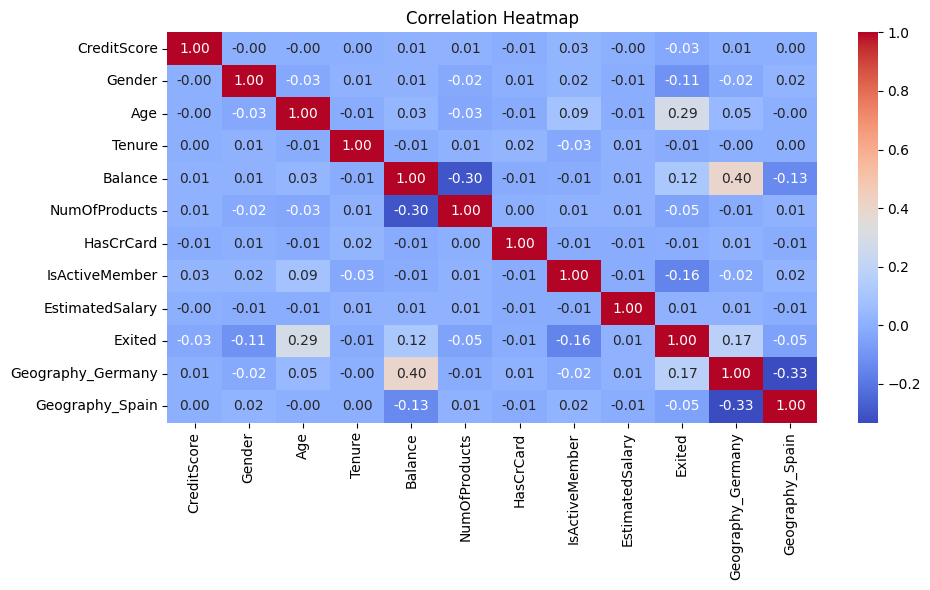

In [48]:
# Create correlation heatmap

plt.figure(figsize=(10,6))

sns.heatmap(
    df_clean.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.tight_layout()

plt.show()

##### Observation

The correlation heatmap provides a visual representation of the relationships between features in the dataset.

Most features exhibit weak correlations with one another, indicating limited multicollinearity within the dataset.

Among the features related to customer churn, Age shows the strongest positive correlation with churn (0.29), suggesting that older customers are more likely to leave the bank.

Geography_Germany also demonstrates a positive correlation with churn (0.17), indicating that customers from Germany tend to exhibit higher churn rates.

Balance has a moderate positive correlation with churn (0.12), suggesting that customers with higher account balances are slightly more likely to exit.

IsActiveMember shows a negative correlation with churn (-0.16), indicating that active customers are less likely to leave the bank.

Most other features, including Credit Score, Tenure, HasCrCard, and Estimated Salary, exhibit relatively weak relationships with customer churn.

Overall, the heatmap confirms that Age, Geography, Balance, and Active Membership are among the most influential factors associated with customer churn.

#### Top Features Correlated with Customer Churn

The correlation analysis identifies the features that are most strongly associated with customer churn.

Understanding these relationships helps highlight important predictors and provides valuable insights for machine learning model development.

In [47]:
# Display correlations with customer churn

df_clean.corr()["Exited"].sort_values(
    ascending=False
)

Exited               1.000000
Age                  0.285323
Geography_Germany    0.173488
Balance              0.118533
EstimatedSalary      0.012097
HasCrCard           -0.007138
Tenure              -0.014001
CreditScore         -0.027094
NumOfProducts       -0.047820
Geography_Spain     -0.052667
Gender              -0.106512
IsActiveMember      -0.156128
Name: Exited, dtype: float64

#### Observation

The feature correlation ranking highlights the variables that are most strongly associated with customer churn.

Age has the strongest positive correlation with churn (0.285), indicating that older customers are more likely to leave the bank.

Geography_Germany exhibits the second-highest positive correlation (0.173), suggesting that customers from Germany have a greater tendency to churn compared to customers from other regions.

Balance also shows a positive correlation with churn (0.119), indicating that customers with higher account balances are slightly more likely to exit.

IsActiveMember has the strongest negative correlation with churn (-0.156), implying that active customers are significantly less likely to leave the bank.

Gender demonstrates a moderate negative correlation (-0.107), while NumOfProducts shows a weaker negative relationship (-0.048).

EstimatedSalary, HasCrCard, Tenure, and CreditScore exhibit very weak correlations with churn, suggesting that these features individually have limited linear relationships with the target variable.

Overall, Age, Geography, Balance, and Active Membership emerge as the most influential predictors of customer churn and are likely to play an important role in machine learning model performance.

### Exploratory Data Analysis (EDA) Summary

The exploratory data analysis provided valuable insights into customer characteristics and factors associated with customer churn.

The dataset contains a balanced representation of customers across multiple demographic and financial attributes, with no missing values or duplicate records identified during data preprocessing.

Several important patterns were observed during the analysis:

- Customer churn is influenced by multiple factors rather than a single variable.
- Older customers exhibit a higher tendency to churn compared to younger customers.
- Customers from Germany demonstrate higher churn behavior than customers from France and Spain.
- Active customers are significantly less likely to leave the bank than inactive customers.
- Customers with two products show the strongest retention, while customers with three or four products exhibit substantially higher churn rates.
- Higher account balances are associated with slightly increased churn.
- Credit card ownership and estimated salary appear to have relatively weak relationships with customer churn.

Correlation analysis further confirmed that Age, Geography, Balance, and Active Membership are among the most influential features associated with customer churn.

These insights provide a strong foundation for machine learning model development and help identify the key factors that may contribute to customer attrition.

## Machine Learning Model Development

After completing data preprocessing and exploratory data analysis, machine learning models are developed to predict customer churn.

The objective is to classify customers as either likely to remain with the bank or likely to exit based on their demographic, financial, and behavioral characteristics.

The dataset is divided into training and testing sets, followed by feature scaling and model training. Model performance is then evaluated using appropriate classification metrics.

### Feature and Target Selection

Before training machine learning models, the dataset is divided into input features and the target variable.

The input features contain customer characteristics used for prediction, while the target variable represents customer churn status.

In [49]:
# Define features and target variable

X = df_clean.drop(
    "Exited",
    axis=1
)

y = df_clean["Exited"]

print("Feature Matrix Shape:", X.shape)
print("Target Variable Shape:", y.shape)

Feature Matrix Shape: (10000, 11)
Target Variable Shape: (10000,)


#### Observation

The dataset was successfully divided into input features and the target variable.

The feature matrix contains 10,000 customer records and 11 predictor variables that will be used for machine learning model training.

The target variable contains 10,000 observations representing customer churn status, where 0 indicates retained customers and 1 indicates customers who exited the bank.

The dimensions confirm that the dataset is correctly prepared for train-test splitting and subsequent machine learning model development.

### Train-Test Split

The dataset is divided into training and testing sets.

The training set is used to train the machine learning models, while the testing set is used to evaluate model performance on unseen data.

An 80-20 split is used, where 80% of the data is allocated for training and 20% for testing.

In [50]:
# Split dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("X_train Shape:", X_train.shape)
print("X_test Shape:", X_test.shape)

print("y_train Shape:", y_train.shape)
print("y_test Shape:", y_test.shape)

X_train Shape: (8000, 11)
X_test Shape: (2000, 11)
y_train Shape: (8000,)
y_test Shape: (2000,)


#### Observation

The dataset was successfully divided into training and testing sets using an 80-20 split ratio.

The training set contains 8,000 customer records and will be used to train the machine learning models.

The testing set contains 2,000 customer records and will be used to evaluate model performance on unseen data.

Both datasets retain the same 11 input features, ensuring consistency between the training and testing phases.

This split provides sufficient data for model learning while reserving an independent dataset for performance evaluation.

### Feature Scaling

Feature scaling is performed to standardize numerical feature values.

Since different features have different ranges, scaling ensures that all variables contribute equally during model training.

StandardScaler is used to transform the features so that they have a mean of 0 and a standard deviation of 1.

In [52]:
# Create scaler object

scaler = StandardScaler()

# Fit and transform training data

X_train_scaled = scaler.fit_transform(
    X_train
)

# Transform testing data

X_test_scaled = scaler.transform(
    X_test
)

print("X_train_scaled Shape:", X_train_scaled.shape)
print("X_test_scaled Shape:", X_test_scaled.shape)

X_train_scaled Shape: (8000, 11)
X_test_scaled Shape: (2000, 11)


#### Observation

Feature scaling was successfully applied using StandardScaler.

The scaler was fitted on the training dataset and then applied to both the training and testing datasets.

This process standardizes the feature values, ensuring that all variables contribute equally during model training regardless of their original scales.

The dimensions of the datasets remain unchanged after scaling, with the training set containing 8,000 records and the testing set containing 2,000 records.

Feature scaling is particularly important for algorithms such as Logistic Regression, as it improves model stability and optimization performance.

### Logistic Regression Model

Logistic Regression is a supervised machine learning algorithm commonly used for binary classification problems.

In this project, Logistic Regression is used to predict whether a customer will remain with the bank or exit based on customer demographic, financial, and behavioral characteristics.

The model is trained using the scaled training dataset and evaluated on unseen testing data.

In [53]:
# Create Logistic Regression model

logistic_model = LogisticRegression(
    random_state=42
)

# Train model

logistic_model.fit(
    X_train_scaled,
    y_train
)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


### Logistic Regression Predictions

After training the Logistic Regression model, predictions are generated using the testing dataset.

These predicted values are compared with the actual customer churn values to evaluate the model's classification performance.

In [54]:
# Generate predictions

y_pred_logistic = logistic_model.predict(
    X_test_scaled
)

print("Predictions generated successfully.")

Predictions generated successfully.


### Logistic Regression Accuracy

Accuracy measures the percentage of correctly classified observations among all predictions.

It provides an overall assessment of the model's ability to predict customer churn on unseen data.

In [55]:
# Calculate accuracy score

logistic_accuracy = accuracy_score(
    y_test,
    y_pred_logistic
)

print(
    "Logistic Regression Accuracy:",
    round(logistic_accuracy, 4)
)

Logistic Regression Accuracy: 0.811


#### Observation

The Logistic Regression model achieved an accuracy of 81.1% on the testing dataset.

This indicates that the model correctly classified approximately 81% of customer records as either retained or churned.

The result suggests that the model is capable of capturing important patterns within the dataset and provides a reasonable baseline for customer churn prediction.

However, accuracy alone does not provide a complete assessment of model performance, particularly when predicting customer churn. Therefore, additional evaluation metrics such as the confusion matrix and classification report are analyzed to gain deeper insights into model behavior.

### Logistic Regression Confusion Matrix

A confusion matrix summarizes the classification results by comparing actual values with predicted values.

It provides detailed information about correct and incorrect predictions, helping evaluate how effectively the model identifies churned and retained customers.

In [57]:
# Generate confusion matrix

cm_logistic = confusion_matrix(
    y_test,
    y_pred_logistic
)

# Create readable confusion matrix table

cm_logistic_df = pd.DataFrame(
    cm_logistic,
    index=[
        "Actual Stayed(0)",
        "Actual Exited(1)"
    ],
    columns=[
        "Predicted Stayed(0)",
        "Predicted Exited(1)"
    ]
)

cm_logistic_df

,Predicted Stayed(0),Predicted Exited(1)
Actual Stayed(0),1543,64
Actual Exited(1),314,79


#### Observation

The confusion matrix provides a detailed summary of the Logistic Regression model's classification performance.

The model correctly classified 1,543 retained customers and 79 churned customers.

A total of 64 retained customers were incorrectly classified as churned, while 314 churned customers were incorrectly classified as retained.

The model demonstrates strong performance in identifying customers who remain with the bank, as evidenced by the high number of correctly classified retained customers.

However, the model struggles to identify churned customers, with a relatively large number of false negatives (314), indicating that many customers who actually exited were predicted to stay.

These findings suggest that while the Logistic Regression model achieves good overall accuracy, its ability to detect churned customers is limited and may require a more advanced model to improve churn prediction performance.

#### Logistic Regression Confusion Matrix Visualization

A heatmap is used to visually represent the confusion matrix.

The heatmap highlights the number of correctly and incorrectly classified observations, making it easier to evaluate the model's prediction performance.

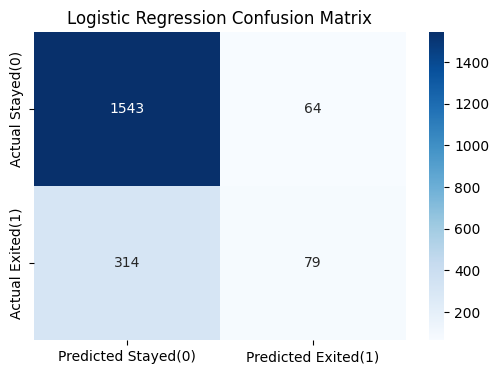

In [61]:
# Create confusion matrix heatmap

plt.figure(figsize=(6,4))

sns.heatmap(
    cm_logistic_df,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title(
    "Logistic Regression Confusion Matrix"
)

plt.show()

#### Observation

The confusion matrix heatmap visually summarizes the classification performance of the Logistic Regression model.

The model correctly classified 1,543 retained customers and 79 churned customers.

A total of 64 retained customers were incorrectly classified as churned, while 314 churned customers were incorrectly classified as retained.

The darker color intensity in the top-left cell indicates that the model performs well in identifying customers who remain with the bank.

However, the relatively high number of false negatives (314) shows that many churned customers are missed by the model.

These results suggest that while Logistic Regression achieves good overall accuracy, its ability to detect customer churn is limited and may be improved using more advanced machine learning models.

### Logistic Regression Classification Report

The classification report provides a detailed evaluation of the Logistic Regression model by measuring precision, recall, and F1-score for each class.

These metrics help assess the model's ability to correctly identify retained and churned customers beyond overall accuracy.

In [58]:
# Generate classification report

print(
    classification_report(
        y_test,
        y_pred_logistic
    )
)

              precision    recall  f1-score   support

           0       0.83      0.96      0.89      1607
           1       0.55      0.20      0.29       393

    accuracy                           0.81      2000
   macro avg       0.69      0.58      0.59      2000
weighted avg       0.78      0.81      0.77      2000



#### Observation

The classification report provides a detailed evaluation of the Logistic Regression model's performance for both retained and churned customers.

For retained customers (Class 0), the model achieved a precision of 0.83, recall of 0.96, and an F1-score of 0.89, indicating strong performance in identifying customers who remain with the bank.

For churned customers (Class 1), the model achieved a precision of 0.55, recall of 0.20, and an F1-score of 0.29.

The low recall for churned customers indicates that the model fails to identify a large proportion of customers who actually exit the bank.

Although the overall accuracy of the model is 81%, the classification report reveals that the model is significantly more effective at predicting retained customers than churned customers.

These findings suggest that Logistic Regression provides a reasonable baseline model but may not be sufficient for accurately detecting customer churn, highlighting the need for a more advanced model such as Random Forest.

### Random Forest Classifier

Random Forest is an ensemble machine learning algorithm that combines multiple decision trees to improve prediction accuracy and reduce overfitting.

Unlike Logistic Regression, Random Forest can capture complex and non-linear relationships between variables, making it highly effective for customer churn prediction.

The model is trained using the training dataset and evaluated on the testing dataset.

In [63]:
# Create Random Forest model

random_forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train model

random_forest_model.fit(
    X_train,
    y_train
)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


### Random Forest Predictions

After training the Random Forest model, predictions are generated using the testing dataset.

These predictions are compared with the actual customer churn values to evaluate the model's classification performance.

In [64]:
# Generate predictions

y_pred_rf = random_forest_model.predict(
    X_test
)

print("Predictions generated successfully.")

Predictions generated successfully.


### Random Forest Accuracy

Accuracy measures the percentage of correctly classified observations among all predictions.

It provides an overall indication of how effectively the Random Forest model predicts customer churn on unseen data.

In [65]:
# Calculate accuracy score

rf_accuracy = accuracy_score(
    y_test,
    y_pred_rf
)

print(
    "Random Forest Accuracy:",
    round(rf_accuracy, 4)
)

Random Forest Accuracy: 0.866


#### Observation

The Random Forest model achieved an accuracy of 86.6% on the testing dataset.

This indicates that the model correctly classified approximately 87% of customer records as either retained or churned.

Compared to Logistic Regression, which achieved an accuracy of 81.1%, Random Forest demonstrates a noticeable improvement in predictive performance.

The higher accuracy suggests that Random Forest is better able to capture complex relationships between customer characteristics and churn behavior.

These results indicate that Random Forest may be a more suitable model for customer churn prediction in this dataset.

### Random Forest Confusion Matrix

A confusion matrix summarizes the classification results by comparing actual customer churn values with the model's predictions.

It provides detailed information about correct and incorrect classifications, helping evaluate the model's ability to identify both retained and churned customers.

In [66]:
# Generate confusion matrix

cm_rf = confusion_matrix(
    y_test,
    y_pred_rf
)

# Create readable confusion matrix table

cm_rf_df = pd.DataFrame(
    cm_rf,
    index=[
        "Actual Stayed(0)",
        "Actual Exited(1)"
    ],
    columns=[
        "Predicted Stayed(0)",
        "Predicted Exited(1)"
    ]
)

cm_rf_df

,Predicted Stayed(0),Predicted Exited(1)
Actual Stayed(0),1552,55
Actual Exited(1),213,180


#### Observation

The confusion matrix provides a detailed summary of the Random Forest model's classification performance.

The model correctly classified 1,552 retained customers and 180 churned customers.

A total of 55 retained customers were incorrectly classified as churned, while 213 churned customers were incorrectly classified as retained.

Compared to Logistic Regression, the Random Forest model significantly improved the identification of churned customers, increasing the number of correctly detected churn cases from 79 to 180.

The model also reduced the number of false negatives from 314 to 213, indicating a stronger ability to identify customers who are likely to leave the bank.

These results demonstrate that Random Forest provides a more balanced and effective classification performance than Logistic Regression for customer churn prediction.

#### Random Forest Confusion Matrix Visualization

A heatmap is used to visually represent the confusion matrix and highlight the distribution of correct and incorrect classifications.

The visualization provides a clear overview of the model's ability to identify retained and churned customers.

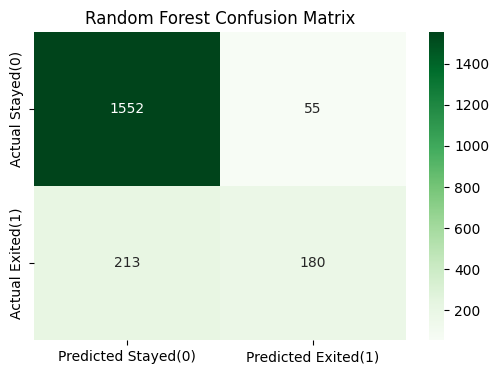

In [68]:
# Create confusion matrix heatmap

plt.figure(figsize=(6,4))

sns.heatmap(
    cm_rf_df,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title("Random Forest Confusion Matrix")

plt.show()

#### Observation

The confusion matrix heatmap visually summarizes the classification performance of the Random Forest model.

The model correctly classified 1,552 retained customers and 180 churned customers, which is higher than the Logistic Regression model.

Only 55 retained customers were incorrectly classified as churned, while 213 churned customers were incorrectly classified as retained.

The darker diagonal cells indicate a high number of correct classifications, demonstrating strong predictive performance.

Compared to Logistic Regression, the Random Forest model significantly improved churn detection and reduced the number of missed churned customers.

Overall, the heatmap confirms that Random Forest provides a more accurate and balanced classification performance for customer churn prediction.

### Random Forest Classification Report

The classification report provides a detailed evaluation of the Random Forest model by measuring precision, recall, and F1-score for each class.

These metrics help assess how effectively the model identifies retained and churned customers and provide a deeper understanding of model performance beyond overall accuracy.

In [71]:
# Generate classification report

print(
    classification_report(
        y_test,
        y_pred_rf
    )
)

              precision    recall  f1-score   support

           0       0.88      0.97      0.92      1607
           1       0.77      0.46      0.57       393

    accuracy                           0.87      2000
   macro avg       0.82      0.71      0.75      2000
weighted avg       0.86      0.87      0.85      2000



#### Observation

The classification report provides a detailed evaluation of the Random Forest model's performance for both retained and churned customers.

For retained customers (Class 0), the model achieved a precision of 0.88, recall of 0.97, and an F1-score of 0.92, indicating excellent performance in identifying customers who remain with the bank.

For churned customers (Class 1), the model achieved a precision of 0.77, recall of 0.46, and an F1-score of 0.57.

Compared to Logistic Regression, the Random Forest model significantly improved the detection of churned customers, increasing recall from 0.20 to 0.46 and F1-score from 0.29 to 0.57.

The overall accuracy of the model reached 86.6%, demonstrating stronger predictive performance than Logistic Regression.

These findings indicate that Random Forest provides a more balanced and effective approach for customer churn prediction and is better suited as the final model for this dataset.

### Model Comparison

To determine the most suitable model for customer churn prediction, the performance of Logistic Regression and Random Forest is compared using accuracy scores.

This comparison helps identify which model provides better predictive performance on unseen testing data.

In [73]:
# Create model comparison table

comparison_df = pd.DataFrame(
    {
        "Model": [
            "Logistic Regression",
            "Random Forest"
        ],
        "Accuracy (%)": [
            logistic_accuracy * 100,
            rf_accuracy * 100
        ]
    }
)

comparison_df["Accuracy (%)"] = (
    comparison_df["Accuracy (%)"]
).round(2)

comparison_df

,Model,Accuracy (%)
0,Logistic Regression,81.1
1,Random Forest,86.6


#### Observation

The model comparison demonstrates that Random Forest achieved an accuracy of 86.6%, outperforming Logistic Regression, which achieved an accuracy of 81.1%.

The improvement of approximately 5.5 percentage points indicates that Random Forest is more effective at learning complex patterns from customer data.

In addition to achieving higher accuracy, Random Forest also showed better performance in identifying churned customers, as reflected by its higher recall and F1-score values.

These results suggest that Random Forest provides a more reliable and balanced approach for customer churn prediction.

Based on the overall evaluation metrics, Random Forest is selected as the final model for this project.

### Feature Importance Analysis

Feature importance measures the contribution of each feature to the Random Forest model's predictions.

This analysis helps identify the factors that have the greatest influence on customer churn and provides valuable business insights for decision-making.

In [74]:
# Create feature importance dataframe

feature_importance = pd.DataFrame(
    {
        "Feature": X.columns,
        "Importance": random_forest_model.feature_importances_
    }
)

# Sort features by importance

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
2,Age,0.239783
8,EstimatedSalary,0.146638
0,CreditScore,0.144214
4,Balance,0.138613
5,NumOfProducts,0.130255
3,Tenure,0.082427
7,IsActiveMember,0.041110
9,Geography_Germany,0.025711
1,Gender,0.019258
6,HasCrCard,0.018722


#### Observation

The feature importance analysis identifies the variables that contribute most to customer churn prediction in the Random Forest model.

Among all features, Age emerged as the most influential factor with an importance score of 0.240, indicating that customer age plays a significant role in churn behavior.

EstimatedSalary (0.147), CreditScore (0.144), Balance (0.139), and NumOfProducts (0.130) were also highly important features, suggesting that financial characteristics and product usage strongly influence customer retention decisions.

Tenure (0.082) and IsActiveMember (0.041) showed moderate importance in predicting churn.

On the other hand, Gender (0.019), HasCrCard (0.019), Geography_Spain (0.013), and Geography_Germany (0.026) contributed relatively less to the model's predictions.

These findings indicate that customer age, financial status, and banking behavior are the primary drivers of customer churn in this dataset.

#### Feature Importance Visualization

A bar chart is used to visualize the importance of each feature in the Random Forest model.

Features with higher importance values contribute more to the model's predictions and have a greater influence on customer churn.

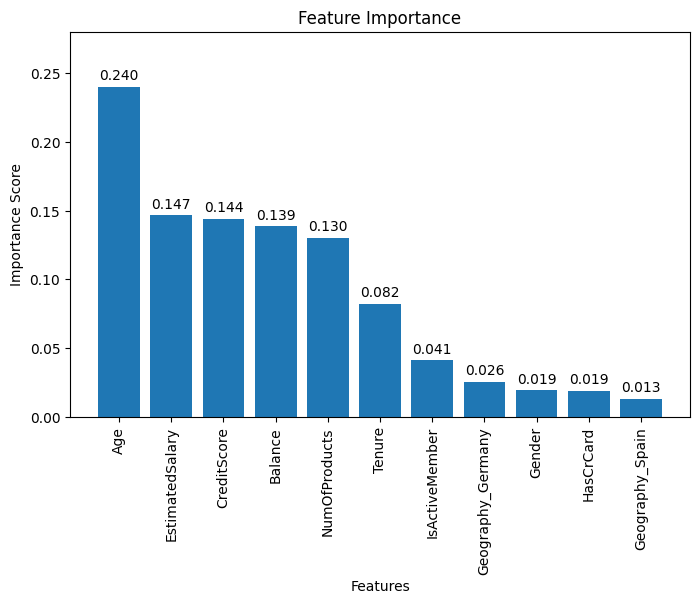

In [83]:
# Create feature importance chart

plt.figure(figsize=(8,5))

bars = plt.bar(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.bar_label(
    bars,
    fmt="%.3f",
    padding=3
)

plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance Score")

plt.xticks(rotation=90)

# Add extra space at top

plt.ylim(0, 0.28)

plt.show()

#### Observation

The feature importance chart visually illustrates the contribution of each feature to the Random Forest model's predictions.

Age is the most influential feature with an importance score of 0.240, indicating that customer age has the strongest impact on churn prediction.

EstimatedSalary (0.147), CreditScore (0.144), Balance (0.139), and NumOfProducts (0.130) are also significant predictors, highlighting the importance of customers' financial status and banking behavior.

Tenure (0.082) and IsActiveMember (0.041) contribute moderately to the model's predictions.

Features such as Gender (0.019), HasCrCard (0.019), Geography_Germany (0.026), and Geography_Spain (0.013) have relatively low importance, suggesting a smaller influence on customer churn.

Overall, the chart confirms that customer age, financial characteristics, and product usage are the primary factors driving churn prediction in this dataset.

## Conclusion

The objective of this project was to analyze customer churn behavior and develop machine learning models capable of predicting whether a customer is likely to leave the bank.

Exploratory Data Analysis (EDA) revealed several important patterns related to customer demographics, geography, account activity, product ownership, and financial characteristics.

Customer churn was found to be associated with factors such as age, account balance, number of products, active membership status, and geographical location.

Two machine learning models were developed and evaluated: Logistic Regression and Random Forest.

The Logistic Regression model achieved an accuracy of 81.1%, providing a reasonable baseline model for churn prediction. However, its ability to identify churned customers was limited, particularly in terms of recall and F1-score.

The Random Forest model achieved an accuracy of 86.6% and significantly improved churn detection performance. It demonstrated better precision, recall, and F1-score values compared to Logistic Regression.

Feature importance analysis showed that Age, Estimated Salary, Credit Score, Balance, and Number of Products were the most influential factors affecting customer churn.

Based on the overall evaluation results, Random Forest was selected as the final model because it provided the highest predictive performance and better identification of customers at risk of leaving the bank.

The findings from this project can help banks better understand customer behavior, improve retention strategies, and proactively reduce customer churn.